In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor


In [3]:
df = pd.read_csv('co2.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
print(df.isnull().sum())
print(df.describe())
print(df.dtypes)

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64
       Engine Size(L)    Cylinders  Fuel Consumption City (L/100 km)  \
count     7385.000000  7385.000000                       7385.000000   
mean         3.160068     5.615030                         12.556534   
std          1.354170     1.828307                          3.500274   
min          0.900000     3.000000                          4.200000   
25%          2.000000     4.000000                         10.100000   
50%          3.000000     6.000000                         12.100000   
75%          3.700000     6

Zamiana wartości opisowych na numeryczne za pomocą LabelEncoder

In [6]:
le = LabelEncoder()

df['marka_encoded'] = le.fit_transform(df['Make'])
df['model_encoded'] = le.fit_transform(df['Model'])
df['transmission_encoded'] = le.fit_transform(df['Transmission'])
df['fuel_type_encoded'] = le.fit_transform(df['Fuel Type'])
df['vehicle_class_encoded'] = le.fit_transform(df['Vehicle Class'])

df.drop(columns=['Make', 'Model', 'Transmission', 'Fuel Type','Vehicle Class'], inplace=True)

df.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),marka_encoded,model_encoded,transmission_encoded,fuel_type_encoded,vehicle_class_encoded
0,2.0,4,9.9,6.7,8.5,33,196,0,1057,14,4,0
1,2.4,4,11.2,7.7,9.6,29,221,0,1057,25,4,0
2,1.5,4,6.0,5.8,5.9,48,136,0,1058,22,4,0
3,3.5,6,12.7,9.1,11.1,25,255,0,1233,15,4,11
4,3.5,6,12.1,8.7,10.6,27,244,0,1499,15,4,11


Macierz korelacji

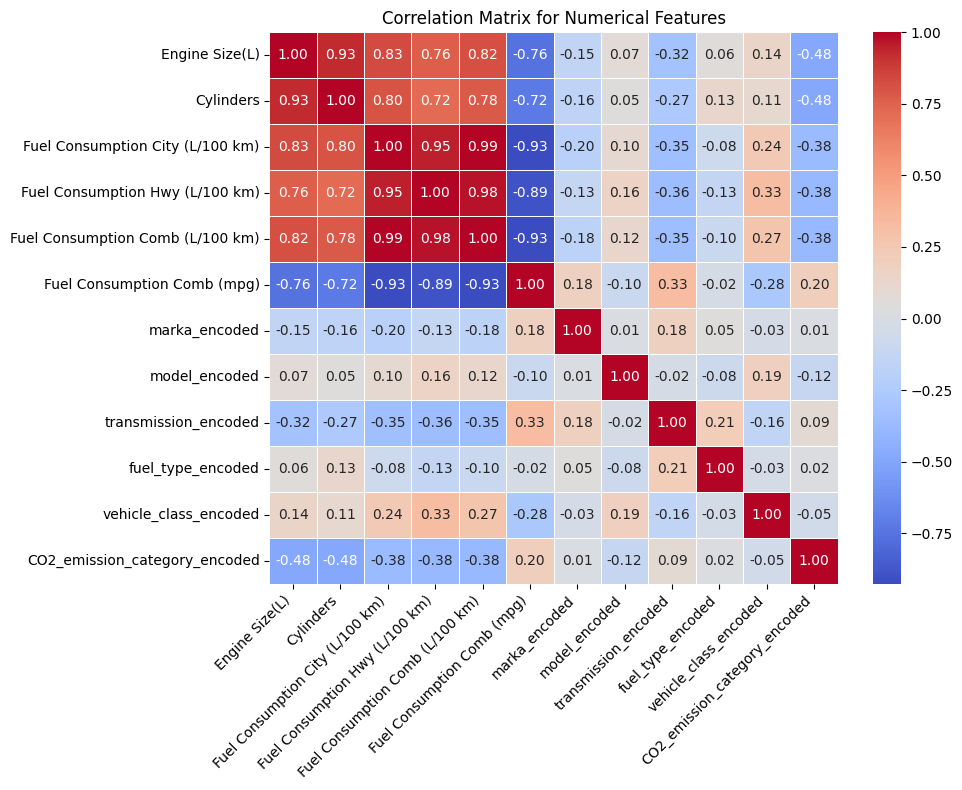

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


Zamiana emisji CO2 na przedziały - niski, średni, wysoki, bardzo wysoki

zamiana wartości opisowych w kolumnie CO2_emission_category na numeryczne

In [9]:
min_value = df['CO2 Emissions(g/km)'].min()
max_value = df['CO2 Emissions(g/km)'].max()

bins = [min_value, 200, 250, 300, max_value+1]
labels = ['niska', 'średnia', 'wysoka', 'bardzo wysoka']
df['CO2_emission_category'] = pd.cut(df['CO2 Emissions(g/km)'], bins=bins, labels=labels, right=False)
df['CO2_emission_category_encoded'] = le.fit_transform(df['CO2_emission_category'])

df.drop(columns=['CO2_emission_category'], inplace=True)
df.drop(columns=['CO2 Emissions(g/km)'], inplace=True)

df.head()
print(df.isnull().sum())

Engine Size(L)                      0
Cylinders                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
marka_encoded                       0
model_encoded                       0
transmission_encoded                0
fuel_type_encoded                   0
vehicle_class_encoded               0
CO2_emission_category_encoded       0
dtype: int64


In [10]:
y = df['CO2_emission_category_encoded']
X = df.drop(['CO2_emission_category_encoded'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((5169, 11), (2216, 11), (5169,), (2216,))

Algorytm Random Forest

In [11]:

random_forest_model = RandomForestRegressor(random_state=42, n_estimators=100)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

random_forest_results = {
    'Model': 'Random Forest',
    'MAE': mae_rf,
    'RMSE': rmse_rf,
    'R2': r2_rf
}
random_forest_results

{'Model': 'Random Forest',
 'MAE': 0.05417470345538937,
 'RMSE': 0.2231275516321072,
 'R2': 0.9593295454007122}

Model Gradient Boosting

In [12]:
gradient_boosting_model = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

gradient_boosting_results = {
    'Model': 'Gradient Boosting',
    'MAE': mae_gb,
    'RMSE': rmse_gb,
    'R2': r2_gb
}
gradient_boosting_results


{'Model': 'Gradient Boosting',
 'MAE': 0.09889833400372836,
 'RMSE': 0.24094934705589244,
 'R2': 0.9525731659687178}

Modele perceptronów wielowartswowych - bazowy i zoptymalizowany

Standaryzacja danych, podział na zbiór treningowy i testowy

In [13]:
df_copy = df.copy()

X = df_copy.drop(columns=['CO2_emission_category_encoded'])
y = df_copy['CO2_emission_category_encoded']

scaler_standard = StandardScaler()

X_standardized = scaler_standard.fit_transform(X)
X_train_standardized, X_test_standardized, y_train_standarized, y_test_standarized = train_test_split(X_standardized, y, test_size=0.2, random_state=42)

In [14]:
mlp_base_model = MLPRegressor(random_state=42, max_iter=1000)

mlp_base_model.fit(X_train_standardized, y_train_standarized)

y_pred_mlp_base = mlp_base_model.predict(X_test_standardized)


mae_mlp_base = mean_absolute_error(y_test_standarized, y_pred_mlp_base)
rmse_mlp_base = np.sqrt(mean_squared_error(y_test_standarized, y_pred_mlp_base))
r2_mlp_base = r2_score(y_test_standarized, y_pred_mlp_base)

mlp_base_results = {
    'Model': 'MLP (Bazowy)',
    'MAE': mae_mlp_base,
    'RMSE': rmse_mlp_base,
    'R2': r2_mlp_base
}

print(mlp_base_results)


{'Model': 'MLP (Bazowy)', 'MAE': 0.2251936332284347, 'RMSE': 0.33589179496245025, 'R2': 0.9083471562115284}


Optymalizacja modelu MLP - wykorzystanie GridSearch do wyszukania najlepszych parametrów

In [15]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (100, 100)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant']
}


mlp_model = MLPRegressor(random_state=42, max_iter=1000)

grid_search = GridSearchCV(mlp_model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_standardized, y_train_standarized)

best_params = grid_search.best_params_
print("Najlepsze parametry:", best_params)

y_pred_mlp_opt = grid_search.predict(X_test_standardized)

mae_mlp_opt = mean_absolute_error(y_test_standarized, y_pred_mlp_opt)
rmse_mlp_opt = np.sqrt(mean_squared_error(y_test_standarized, y_pred_mlp_opt))
r2_mlp_opt = r2_score(y_test_standarized, y_pred_mlp_opt)

mlp_opt_results = {
    'Model': 'MLP (Zoptymalizowany)',
    'MAE': mae_mlp_opt,
    'RMSE': rmse_mlp_opt,
    'R2': r2_mlp_opt
}

print(mlp_opt_results)


Najlepsze parametry: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100), 'learning_rate': 'constant', 'solver': 'adam'}
{'Model': 'MLP (Zoptymalizowany)', 'MAE': 0.13610326384605848, 'RMSE': 0.27199288218417933, 'R2': 0.9399016937451518}
